In [ ]:
#imports
import numpy as np
from utils import objects as ob
from utils import soa as SOA

UsageError: Line magic function `%autoreload` not found.


In [ ]:
#intializing multibodysystem
robot = ob.MultiBodySystem()

#defining joints
joint1 = ob.FreeJoint()
joint2 = ob.SphericalJoint()
joint3 = ob.RevoluteJoint(axis="z")    

#intialziing such that pendulum is hanging to the right

joint1.q_init = np.concatenate((SOA.quatfromrev(np.pi/2,"y"), np.zeros(3)))
joint2.w_init = np.array([1,1,2])

#defining links
link1 = ob.Link(mass=2.0, l_hinge=np.array([0, 0, 0.2]), joint=joint1)
link2 = ob.Link(mass=1.0, l_hinge=np.array([0, 0, 0.2]), joint=joint2)
link3 = ob.Link(mass=0.5, l_hinge=np.array([0, 0, 0.2]), joint=joint3)

#adding links - build base out
robot.add_link(link3)
robot.add_link(link2)
robot.add_link(link1)


In [3]:
#parameters for ssimulation
tspan = np.arange(0,10,0.001)
V_base = np.zeros(6)
A_base = np.zeros(6)
A_base[-1] = 9.81 #simulating gravity in z

robot.simulate_open(tspan,V_base,A_base)

simulation started
t = 0.00 s
t = 1.00 s
t = 2.00 s
t = 3.00 s
t = 4.00 s
t = 5.00 s
t = 6.00 s
t = 7.00 s
t = 8.00 s
t = 9.00 s
simulation finished


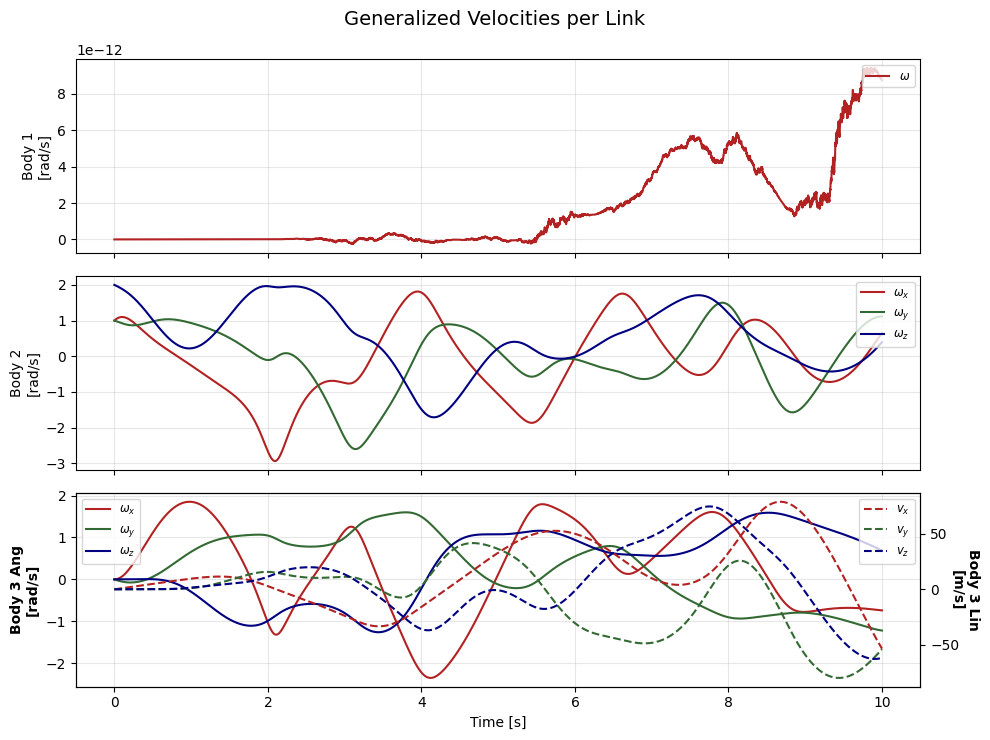

In [4]:
robot.plot_gen_velocities()

In [8]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

omega, radius = 2.0, 0.2
fig, ax = plt.subplots()
ax.set_xlim(-0.3, 0.3); ax.set_ylim(-0.3, 0.3); ax.set_aspect('equal')

point, = ax.plot([], [], 'ro')
line, = ax.plot([], [], 'r-')

def update(frame):
    t = frame / 30
    x, z = radius * np.cos(omega * t), radius * np.sin(omega * t)
    point.set_data([x], [z])
    line.set_data([0, x], [0, z])
    return point, line

ani = FuncAnimation(fig, update, frames=150, interval=33, blit=True)
plt.show()

RuntimeError: 'widget' is not a recognised GUI loop or backend name